In order to use the animation features we have to install ipympl 

$pip install ipympl

In [1]:
%matplotlib ipympl 
import numpy as np
import matplotlib.pyplot as plt
from IsingArray import *
# from IsingEnsemble import *

## First Animation
The simplest way to use this library is to initialize an array and use the animation feature

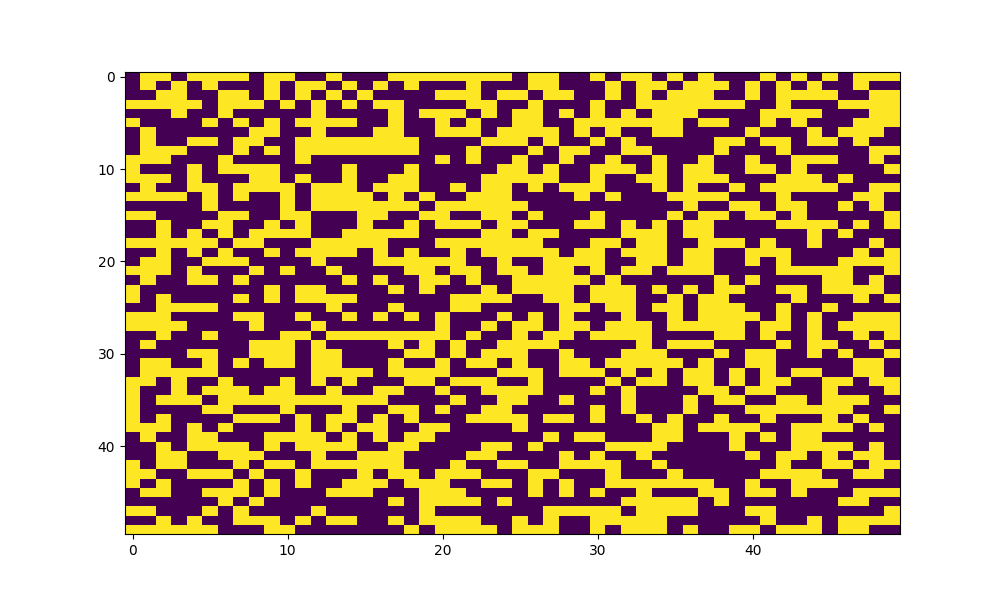

In [2]:
shape = (50, 50) # dimensions of Array
J = 1
kb = 1 
T = 1 # w/J=kb=1, the critical temperature is Tc~2.2, so this array will form a net magnitization
Array1 = IsingArray(shape, T, J, kb)
ani = Array1.animate(show = False, loop = False)
ani;

## State Variables
If we want to see how the state variables of this array (or a few different arrays) evolve over the course of the run, we can do that too

For T < Tc, we should see the total energy crater over the run time and a net magnetization emerge, whereas for T>Tc the total energy will decrease only slightly from a completely random setup, and the magnetization will remain close to zeros

### Single Array
First lets examine a single array

The use case of single array is to track how state variables evolve over the course of a run

In [3]:
Array2 = IsingArray(shape, T , J, kb ) #Initialize a new array 
Array2.sweep(1000) #Update Array 1000 times

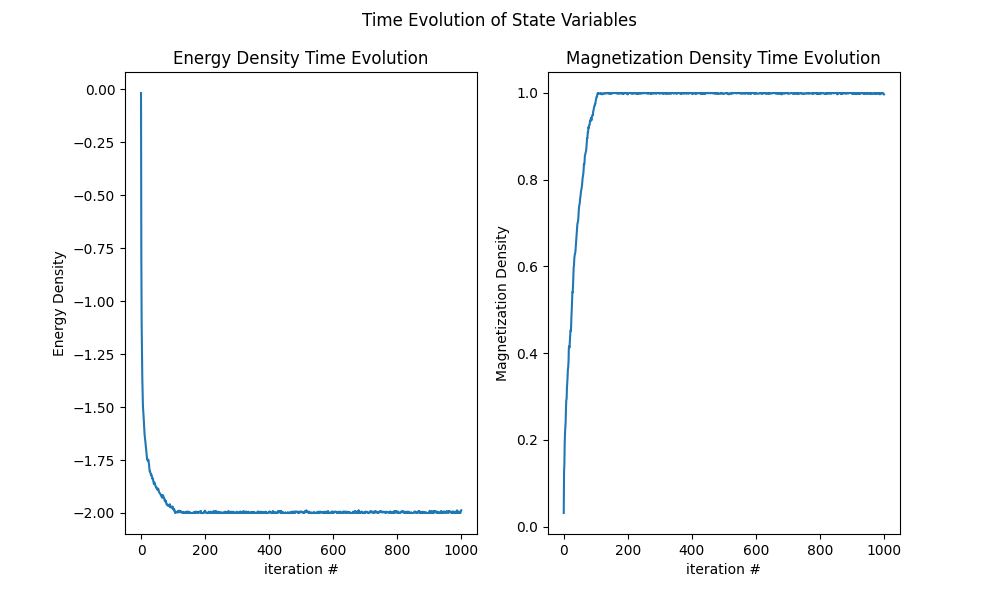

In [4]:
#Plot the evolution of state variables        
f, (axE, axM) = plt.subplots(1,2, figsize = (10, 6))
f.suptitle("Time Evolution of State Variables")
axE.plot(Array2.E_v)
axM.plot(Array2.M_v)
    
axE.set_xlabel("iteration #")
axE.set_ylabel("Energy Density")
axE.set_title("Energy Density Time Evolution")

axM.set_xlabel("iteration #")
axM.set_ylabel("Magnetization Density")
axM.set_title("Magnetization Density Time Evolution")

plt.show()

### Ensemble of Arrays
If we want to observe the phase change in detail, it is better to use the IsingEnsemble class

In [5]:
from IsingEnsemble import *

In [6]:
n = 100
shape = (20, 20)
T = np.linspace(0.5, 5, n)
J = 1
kb = 1

MyEnsemble = IsingEnsemble(n, shape, T, J, kb)
MyEnsemble.sweep(1000)

In [7]:
#To Handle thermal fluctuations we will average over a couple runs 
E_v = np.zeros(n, 20)
M_v = np.zeros(n, 20)
for i in range(20):
    MyEnsemble.sweep()
    E_v[:, i] = MyEnsemble.get_energy()
    M_v[:, i] = MyEnsemble.get_mag()
    
E = np.mean(E_v, axis = 1)
M = np.mean(M_v, axis = 1)

TypeError: Cannot interpret '20' as a data type

In [ ]:
#Plot state variables against temp range      
f, (axE, axM) = plt.subplots(1,2, figsize = (10, 6))
f.suptitle("Time Evolution of State Variables")
axE.scatter(T, E)
axM.scatter(T, M)
    
axE.set_xlabel("Temperature")
axE.set_ylabel("Energy Density")
axE.set_title("Energy Density vs Temp")

axM.set_xlabel("Temperature")
axM.set_ylabel("Magnetization Density")
axM.set_title("Magnetization Density vs Temp")

plt.show()